# Neural Network signal vs. background

## INSTALLING THE REQUIRED DEPENDENCIES

Required python libraries (already in the container, installed via the dockerfile)

In [1]:
# !pip install numpy uproot scikit-learn matplotlib pandas seaborn tensorflow gdown awkward

## START IMPORT

Importing the needed modules

In [2]:
import os
import sys
import time

import numpy as np
import uproot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_curve, roc_auc_score, f1_score, precision_score, classification_report, confusion_matrix)

import gdown

from pathlib import Path

import awkward

I0000 00:00:1783437775.834746     133 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783437775.837133     133 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783437775.951059     133 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783437778.642956     133 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

## DATA PREPARATION (1)

Downloading the dataset from Google Drive (the file will be downloaded only if it's not already present)

In [3]:
# Create the dataset folder (only if not already present)
Path("dataset").mkdir(parents=True,
                      exist_ok=True)

file_id     = "1LWOF7HsE8sJUUWZylVmuxRyKVr5Yyi_K" # Google Drive file ID
output_file = Path("dataset/SB_simul.root")       # Path in which look for the file and (if it's not already there) download it

min_size_gb    = 2.0
min_size_bytes = min_size_gb * 1024**3

# Checks if there's already a file and if it's big enough
if output_file.exists() and output_file.stat().st_size > min_size_bytes:
    print(f"File already present: {output_file}")
    print(f"Dimension: {output_file.stat().st_size / 1024**3:.2f} GB")
else:
    print("File not found or incomplete. Starting download...")
    gdown.download(
        id     = file_id,
        output = str(output_file),
        quiet  = False
    )

File already present: dataset/SB_simul.root
Dimension: 2.10 GB


In [4]:
# ROOT file path
file1_path = 'dataset/SB_simul.root'

# tree names
treeS_name = "TreeS"
treeB_name = "TreeB"

### Load data

In [5]:
# Loading data
file1 = uproot.open(file1_path)

# check the path
file1_path

'dataset/SB_simul.root'

In [6]:
# Extract signal and background trees
treeS = file1[treeS_name]
treeB = file1[treeB_name]

# Print what imported
print(treeS)
print(treeB)

<TTree 'TreeS' (13 branches) at 0x7ccb68fad9d0>
<TTree 'TreeB' (13 branches) at 0x7ccb67f3d6d0>


In [7]:
treeS.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
massK0S              | float                    | AsDtype('>f4')
tImpParBach          | float                    | AsDtype('>f4')
tImpParV0            | float                    | AsDtype('>f4')
CtK0S                | float                    | AsDtype('>f4')
cosPAK0S             | float                    | AsDtype('>f4')
nSigmapr             | float                    | AsDtype('>f4')
dcaV0                | float                    | AsDtype('>f4')
bachelorPt           | float                    | AsDtype('>f4')
v0Pt                 | float                    | AsDtype('>f4')
massLc2K0Sp          | float                    | AsDtype('>f4')
LcPt                 | float                    | AsDtype('>f4')
origin               | float                    | AsDtype('>f4')
asymmPt              | float                    | AsDtype(

In [8]:
treeB.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
massK0S              | float                    | AsDtype('>f4')
tImpParBach          | float                    | AsDtype('>f4')
tImpParV0            | float                    | AsDtype('>f4')
CtK0S                | float                    | AsDtype('>f4')
cosPAK0S             | float                    | AsDtype('>f4')
nSigmapr             | float                    | AsDtype('>f4')
dcaV0                | float                    | AsDtype('>f4')
bachelorPt           | float                    | AsDtype('>f4')
v0Pt                 | float                    | AsDtype('>f4')
massLc2K0Sp          | float                    | AsDtype('>f4')
LcPt                 | float                    | AsDtype('>f4')
origin               | float                    | AsDtype('>f4')
asymmPt              | float                    | AsDtype(

## PRELIMINARY ANALYSIS ON THE DATASET

In [9]:
# Create the preliminary_analysis folder (only if not already present)
Path("preliminary_analysis").mkdir(parents=True,
                                   exist_ok=True)

### DATA LOADING

In [10]:
# Creates the directory if it does not exist
output_folder = "./preliminary_analysis"


# Extracting the varibales from the sgn and bkg trees
massK0S_sig     = treeS["massK0S"].array()
tImpParBach_sig = treeS["tImpParBach"].array()
tImpParV0_sig   = treeS["tImpParV0"].array()
CtK0S_sig       = treeS["CtK0S"].array()
cosPAK0S_sig    = treeS["cosPAK0S"].array()
nSigmapr_sig    = treeS["nSigmapr"].array()
dcaV0_sig       = treeS["dcaV0"].array()

massK0S_bkg     = treeB["massK0S"].array()
tImpParBach_bkg = treeB["tImpParBach"].array()
tImpParV0_bkg   = treeB["tImpParV0"].array()
CtK0S_bkg       = treeB["CtK0S"].array()
cosPAK0S_bkg    = treeB["cosPAK0S"].array()
nSigmapr_bkg    = treeB["nSigmapr"].array()
dcaV0_bkg       = treeB["dcaV0"].array()


# Converting the tree arrays to numpy arrays
massK0S_sig_np     = massK0S_sig.to_numpy()
tImpParBach_sig_np = tImpParBach_sig.to_numpy()
tImpParV0_sig_np   = tImpParV0_sig.to_numpy()
CtK0S_sig_np       = CtK0S_sig.to_numpy()
cosPAK0S_sig_np    = cosPAK0S_sig.to_numpy()
nSigmapr_sig_np    = nSigmapr_sig.to_numpy()
dcaV0_sig_np       = dcaV0_sig.to_numpy()

massK0S_bkg_np     = massK0S_bkg.to_numpy()
tImpParBach_bkg_np = tImpParBach_bkg.to_numpy()
tImpParV0_bkg_np   = tImpParV0_bkg.to_numpy()
CtK0S_bkg_np       = CtK0S_bkg.to_numpy()
cosPAK0S_bkg_np    = cosPAK0S_bkg.to_numpy()
nSigmapr_bkg_np    = nSigmapr_bkg.to_numpy()
dcaV0_bkg_np       = dcaV0_bkg.to_numpy()

### HISTOGRAMS

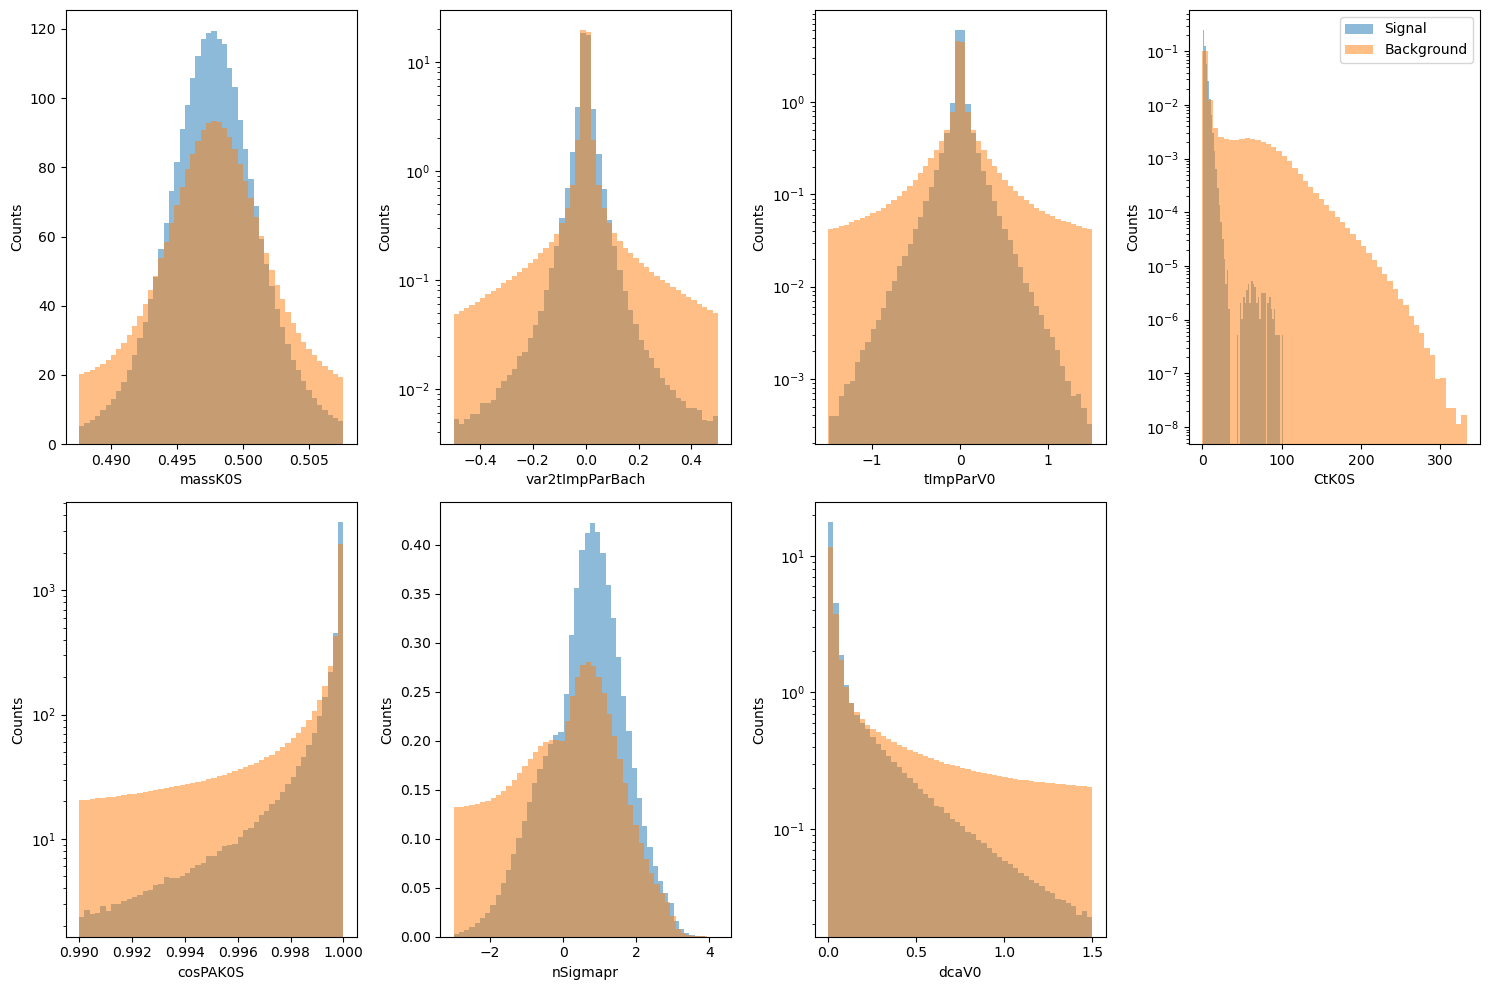

In [11]:
# Plotting the histogram for all the variables
plt.figure(figsize=(15, 10))


plt.subplot(2, 4, 1)
plt.hist(massK0S_sig, bins=50, alpha=0.5, density=True, label='Signal')
plt.hist(massK0S_bkg, bins=50, alpha=0.5, density=True, label='Background')
plt.xlabel('massK0S')
plt.ylabel('Counts')
#plt.legend()

plt.subplot(2, 4, 2)
plt.hist(tImpParBach_sig, bins=50, alpha=0.5, density=True, label='Signal')
plt.hist(tImpParBach_bkg, bins=50, alpha=0.5, density=True, label='Background')
plt.xlabel('var2tImpParBach')
plt.ylabel('Counts')
plt.yscale('log')
#plt.legend()

plt.subplot(2, 4, 3)
plt.hist(tImpParV0_sig, bins=50, alpha=0.5, density=True, label='Signal')
plt.hist(tImpParV0_bkg, bins=50, alpha=0.5, density=True, label='Background')
plt.xlabel('tImpParV0')
plt.ylabel('Counts')
plt.yscale('log')
#plt.legend()

plt.subplot(2, 4, 4)
plt.hist(CtK0S_sig, bins=50, alpha=0.5, density=True, label='Signal')
plt.hist(CtK0S_bkg, bins=50, alpha=0.5, density=True, label='Background')
plt.xlabel('CtK0S')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

plt.subplot(2, 4, 5)
plt.hist(cosPAK0S_sig, bins=50, alpha=0.5, density=True, label='Signal')
plt.hist(cosPAK0S_bkg, bins=50, alpha=0.5, density=True, label='Background')
plt.xlabel('cosPAK0S')
plt.ylabel('Counts')
plt.yscale('log')
#plt.legend()

plt.subplot(2, 4, 6)
plt.hist(nSigmapr_sig, bins=50, alpha=0.5, density=True, label='Signal')
plt.hist(nSigmapr_bkg, bins=50, alpha=0.5, density=True, label='Background')
plt.xlabel('nSigmapr')
plt.ylabel('Counts')
#plt.legend()

plt.subplot(2, 4, 7)
plt.hist(dcaV0_sig, bins=50, alpha=0.5, density=True, label='Signal')
plt.hist(dcaV0_bkg, bins=50, alpha=0.5, density=True, label='Background')
plt.xlabel('dcaV0')
plt.ylabel('Counts')
plt.yscale('log')
#plt.legend()


# Saves figure on the file
plt.savefig(os.path.join(output_folder, "vars_histogram.pdf"))
plt.tight_layout()
plt.show()

### CORRELATION MATRICES

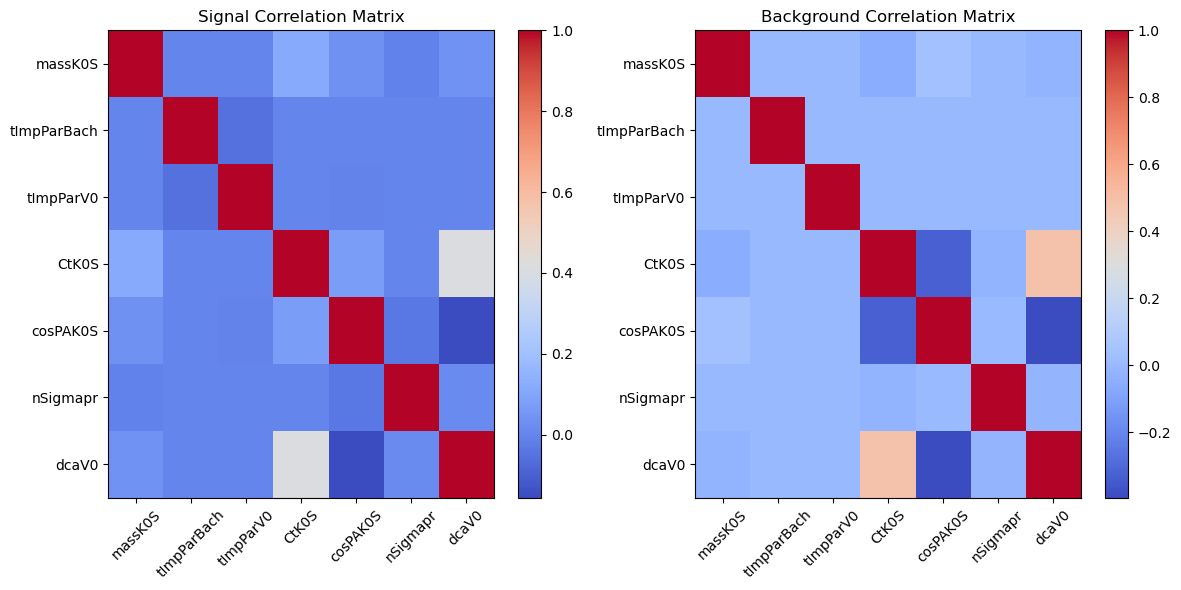

In [12]:
# Put the numpy arrays of each variable into columns and then calculate the transposed
X_signal = np.vstack((massK0S_sig_np,
                      tImpParBach_sig_np,
                      tImpParV0_sig_np,
                      CtK0S_sig_np,
                      cosPAK0S_sig_np,
                      nSigmapr_sig_np,
                      dcaV0_sig_np)).T

X_background = np.vstack((massK0S_bkg_np,
                          tImpParBach_bkg_np,
                          tImpParV0_bkg_np,
                          CtK0S_bkg_np,
                          cosPAK0S_bkg_np,
                          nSigmapr_bkg_np,
                          dcaV0_bkg_np)).T


# Computing correlation matrix
# rowvar=False means that the columns represent the variables and the rows the observations
signal_corr_matrix = np.corrcoef(X_signal,
                                 rowvar=False)

background_corr_matrix = np.corrcoef(X_background,
                                     rowvar=False)


# Definition of the variables name
variable_names = ['massK0S',
                  'tImpParBach',
                  'tImpParV0',
                  'CtK0S',
                  'cosPAK0S',
                  'nSigmapr',
                  'dcaV0']


# Plot of the correlation matrix
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(signal_corr_matrix,
           cmap='coolwarm',
           aspect='auto')
plt.title('Signal Correlation Matrix')
plt.xticks(ticks=np.arange(len(variable_names)),
           labels=variable_names,
           rotation=45)
plt.yticks(ticks=np.arange(len(variable_names)),
           labels=variable_names)
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(background_corr_matrix,
           cmap='coolwarm',
           aspect='auto')
plt.title('Background Correlation Matrix')
plt.xticks(ticks=np.arange(len(variable_names)),
           labels=variable_names,
           rotation=45)
plt.yticks(ticks=np.arange(len(variable_names)),
           labels=variable_names)
plt.colorbar()


# Saves figure con the file
plt.savefig(os.path.join(output_folder,
                         "correlation_matrixes.pdf"))
plt.tight_layout()
plt.show()

## DATA PREPARATION (2)

#### Load data from Trees into Pandas DataFrames (df)

In [13]:
df_signal = treeS.arrays(library = "pd")

df_signal

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0,bachelorPt,v0Pt,massLc2K0Sp,LcPt,origin,asymmPt
0,0.501015,0.002563,-0.018624,1.561310,0.999881,1.379819,0.012402,1.494723,0.657968,2.289467,1.287097,5.0,0.388702
1,0.498554,0.006365,0.429775,3.831764,0.997924,0.202202,0.078762,1.148710,0.863184,2.290424,1.326933,5.0,0.141919
2,0.499140,0.043404,-0.019748,1.008557,0.999953,0.394361,0.007458,1.071459,1.261988,2.288031,1.621147,5.0,-0.081651
3,0.492339,-0.000342,0.011495,0.367885,0.999529,1.677530,0.009267,1.068153,1.007324,2.277980,1.273440,5.0,0.029308
4,0.496173,-0.073643,0.246707,3.753914,0.999609,1.095001,0.920251,0.723837,1.323777,2.285922,1.706256,5.0,-0.292995
...,...,...,...,...,...,...,...,...,...,...,...,...,...
943640,0.499240,0.004190,0.027761,0.570992,0.999818,0.991573,0.026876,0.916397,1.278712,2.281716,1.491507,5.0,-0.165056
943641,0.500042,-0.000711,0.290690,10.120708,0.999901,1.864643,0.579110,1.081626,1.002655,2.286515,1.131780,5.0,0.037889
943642,0.497493,-0.053349,0.056918,3.069903,0.999974,-0.995700,0.011193,0.628474,1.110416,2.286527,1.227481,5.0,-0.277155
943643,0.501001,0.005253,0.020308,0.980737,0.999701,-1.666190,0.028961,1.637398,0.561509,2.276654,1.375886,5.0,0.489284


In [14]:
df_background = treeB.arrays(library = "pd")

df_background

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0,bachelorPt,v0Pt,massLc2K0Sp,LcPt,origin,asymmPt
0,0.497245,-0.043013,-0.004528,2.556512,0.999998,-0.452066,0.017104,0.420924,1.747855,2.462304,1.429823,-1.0,-0.611834
1,0.497012,0.005981,-0.025221,1.455961,0.999940,0.187446,0.009095,0.494504,1.245030,2.165277,1.040291,-1.0,-0.431453
2,0.505080,0.022939,-0.003785,0.080898,0.996212,0.460292,0.031412,0.572067,1.356922,2.124467,1.790542,-1.0,-0.406873
3,0.499342,-0.008351,-0.010375,1.467479,0.999989,1.402289,0.001994,1.369383,0.834325,2.105740,1.957422,-1.0,0.242799
4,0.494041,-0.006271,-0.001192,0.447153,0.999125,-1.857860,0.052720,1.347346,0.681790,2.213034,1.508441,-1.0,0.328000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26849768,0.488910,0.206418,0.089082,1.124604,0.998503,-0.200791,0.229895,1.416834,0.755706,2.316674,1.212868,-1.0,0.304311
26849769,0.494111,0.000832,-0.007204,0.439936,0.999581,0.383316,0.064410,1.401958,0.534967,2.156958,1.228046,-1.0,0.447612
26849770,0.504458,0.167190,0.112703,35.785530,0.999968,-0.481222,1.211956,1.544939,0.706098,2.217232,1.598873,-1.0,0.372647
26849771,0.503800,0.003915,-0.840921,72.546837,0.996647,-2.491238,1.239423,1.400697,0.799472,2.255564,1.357744,-1.0,0.273263


### Prepare data
Prepare data for the training and evaluation of a classification model.

In [15]:
feature_names = ["massK0S",
                 "tImpParBach",
                 "tImpParV0",
                 "CtK0S",
                 "cosPAK0S",
                 "nSigmapr",
                 "dcaV0"]

feature_names

['massK0S',
 'tImpParBach',
 'tImpParV0',
 'CtK0S',
 'cosPAK0S',
 'nSigmapr',
 'dcaV0']

#### Select features


In [16]:
X_signal = df_signal[feature_names]

X_signal

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
0,0.501015,0.002563,-0.018624,1.561310,0.999881,1.379819,0.012402
1,0.498554,0.006365,0.429775,3.831764,0.997924,0.202202,0.078762
2,0.499140,0.043404,-0.019748,1.008557,0.999953,0.394361,0.007458
3,0.492339,-0.000342,0.011495,0.367885,0.999529,1.677530,0.009267
4,0.496173,-0.073643,0.246707,3.753914,0.999609,1.095001,0.920251
...,...,...,...,...,...,...,...
943640,0.499240,0.004190,0.027761,0.570992,0.999818,0.991573,0.026876
943641,0.500042,-0.000711,0.290690,10.120708,0.999901,1.864643,0.579110
943642,0.497493,-0.053349,0.056918,3.069903,0.999974,-0.995700,0.011193
943643,0.501001,0.005253,0.020308,0.980737,0.999701,-1.666190,0.028961


In [17]:
X_background = df_background[feature_names]

X_background

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
0,0.497245,-0.043013,-0.004528,2.556512,0.999998,-0.452066,0.017104
1,0.497012,0.005981,-0.025221,1.455961,0.999940,0.187446,0.009095
2,0.505080,0.022939,-0.003785,0.080898,0.996212,0.460292,0.031412
3,0.499342,-0.008351,-0.010375,1.467479,0.999989,1.402289,0.001994
4,0.494041,-0.006271,-0.001192,0.447153,0.999125,-1.857860,0.052720
...,...,...,...,...,...,...,...
26849768,0.488910,0.206418,0.089082,1.124604,0.998503,-0.200791,0.229895
26849769,0.494111,0.000832,-0.007204,0.439936,0.999581,0.383316,0.064410
26849770,0.504458,0.167190,0.112703,35.785530,0.999968,-0.481222,1.211956
26849771,0.503800,0.003915,-0.840921,72.546837,0.996647,-2.491238,1.239423


#### Start Normalisation

Normalize SIGNAL dataset by dividing by the maximum value of each variable

In [18]:
# Take the max
max_massK0S_signal     = X_signal["massK0S"].max()
max_tImpParBach_signal = X_signal["tImpParBach"].max()
max_tImpParV0_signal   = X_signal["tImpParV0"].max()
max_CtK0S_signal       = X_signal["CtK0S"].max()
max_cosPAK0S_signal    = X_signal["cosPAK0S"].max()
max_nSigmapr_signal    = X_signal["nSigmapr"].max()
max_dcaV0_signal       = X_signal["dcaV0"].max()

X_signal_normalized = pd.DataFrame()

# Divide_signal
X_signal_normalized["massK0S"]     = X_signal["massK0S"]     / max_massK0S_signal
X_signal_normalized["tImpParBach"] = X_signal["tImpParBach"] / max_tImpParBach_signal
X_signal_normalized["tImpParV0"]   = X_signal["tImpParV0"]   / max_tImpParV0_signal
X_signal_normalized["CtK0S"]       = X_signal["CtK0S"]       / max_CtK0S_signal
X_signal_normalized["cosPAK0S"]    = X_signal["cosPAK0S"]    / max_cosPAK0S_signal
X_signal_normalized["nSigmapr"]    = X_signal["nSigmapr"]    / max_nSigmapr_signal
X_signal_normalized["dcaV0"]       = X_signal["dcaV0"]       / max_dcaV0_signal

X_signal_normalized

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
0,0.987000,0.005126,-0.012468,0.015291,0.999881,0.330775,0.008268
1,0.982152,0.012732,0.287732,0.037526,0.997924,0.048472,0.052508
2,0.983307,0.086824,-0.013221,0.009877,0.999953,0.094537,0.004972
3,0.969909,-0.000684,0.007696,0.003603,0.999529,0.402143,0.006178
4,0.977463,-0.147312,0.165169,0.036764,0.999609,0.262497,0.613505
...,...,...,...,...,...,...,...
943640,0.983504,0.008381,0.018586,0.005592,0.999818,0.237703,0.017918
943641,0.985084,-0.001423,0.194616,0.099116,0.999901,0.446998,0.386076
943642,0.980062,-0.106716,0.038107,0.030065,0.999974,-0.238692,0.007462
943643,0.986973,0.010507,0.013596,0.009605,0.999701,-0.399424,0.019308


Normalize BACKGROUND dataset by dividing by the maximum value of each variable

In [19]:
# Take the max
max_massK0S_background     = X_background["massK0S"].max()
max_tImpParBach_background = X_background["tImpParBach"].max()
max_tImpParV0_background   = X_background["tImpParV0"].max()
max_CtK0S_background       = X_background["CtK0S"].max()
max_cosPAK0S_background    = X_background["cosPAK0S"].max()
max_nSigmapr_background    = X_background["nSigmapr"].max()
max_dcaV0_background       = X_background["dcaV0"].max()

X_background_normalized = pd.DataFrame()

# Divide_background
X_background_normalized["massK0S"]     = X_background["massK0S"]     / max_massK0S_background
X_background_normalized["tImpParBach"] = X_background["tImpParBach"] / max_tImpParBach_background
X_background_normalized["tImpParV0"]   = X_background["tImpParV0"]   / max_tImpParV0_background
X_background_normalized["CtK0S"]       = X_background["CtK0S"]       / max_CtK0S_background
X_background_normalized["cosPAK0S"]    = X_background["cosPAK0S"]    / max_cosPAK0S_background
X_background_normalized["nSigmapr"]    = X_background["nSigmapr"]    / max_nSigmapr_background
X_background_normalized["dcaV0"]       = X_background["dcaV0"]       / max_dcaV0_background

X_background_normalized

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
0,0.979572,-0.086025,-0.003019,0.007670,0.999998,-0.106729,0.011402
1,0.979115,0.011961,-0.016814,0.004368,0.999940,0.044254,0.006064
2,0.995008,0.045878,-0.002523,0.000243,0.996212,0.108671,0.020942
3,0.983705,-0.016702,-0.006916,0.004403,0.999989,0.331068,0.001330
4,0.973262,-0.012541,-0.000794,0.001342,0.999125,-0.438624,0.035147
...,...,...,...,...,...,...,...
26849768,0.963154,0.412837,0.059388,0.003374,0.998503,-0.047405,0.153263
26849769,0.973400,0.001664,-0.004803,0.001320,0.999581,0.090497,0.042940
26849770,0.993783,0.334381,0.075135,0.107362,0.999968,-0.113612,0.807971
26849771,0.992487,0.007830,-0.560614,0.217651,0.996647,-0.588159,0.826282


Truncate the BACKGROUND dataset to match the same number of events of the SIGNAL one

In [20]:
bkg_max = 943645

X_background_normalized[:bkg_max]

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
0,0.979572,-0.086025,-0.003019,0.007670,0.999998,-0.106729,0.011402
1,0.979115,0.011961,-0.016814,0.004368,0.999940,0.044254,0.006064
2,0.995008,0.045878,-0.002523,0.000243,0.996212,0.108671,0.020942
3,0.983705,-0.016702,-0.006916,0.004403,0.999989,0.331068,0.001330
4,0.973262,-0.012541,-0.000794,0.001342,0.999125,-0.438624,0.035147
...,...,...,...,...,...,...,...
943640,0.972058,0.007930,-0.001359,0.003570,0.999995,-0.516423,0.001118
943641,0.961141,0.019267,0.032449,0.007391,0.999983,0.057793,0.017136
943642,0.980433,-0.003765,-0.155868,0.011146,0.994395,0.348513,0.189550
943643,0.966688,-0.004010,0.037481,0.013495,0.998602,0.126529,0.788198


Concatenate normalized DataFrames (limiting the amount of bkg)

In [21]:
X = pd.concat([X_signal_normalized,
               X_background_normalized[:bkg_max]])

X

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
0,0.987000,0.005126,-0.012468,0.015291,0.999881,0.330775,0.008268
1,0.982152,0.012732,0.287732,0.037526,0.997924,0.048472,0.052508
2,0.983307,0.086824,-0.013221,0.009877,0.999953,0.094537,0.004972
3,0.969909,-0.000684,0.007696,0.003603,0.999529,0.402143,0.006178
4,0.977463,-0.147312,0.165169,0.036764,0.999609,0.262497,0.613505
...,...,...,...,...,...,...,...
943640,0.972058,0.007930,-0.001359,0.003570,0.999995,-0.516423,0.001118
943641,0.961141,0.019267,0.032449,0.007391,0.999983,0.057793,0.017136
943642,0.980433,-0.003765,-0.155868,0.011146,0.994395,0.348513,0.189550
943643,0.966688,-0.004010,0.037481,0.013495,0.998602,0.126529,0.788198


Add a "target" column to distinguish signal (1) from background (0)

In [22]:
y = np.concatenate([np.ones(len(X_signal_normalized)),
                    np.zeros(len(X_background_normalized[:bkg_max]))])

y

array([1., 1., 1., ..., 0., 0., 0.], shape=(1887290,))

Split data into training and test sets (```test_size = 0.2```)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size    = 0.2,
    random_state = 42,
    shuffle      = True
)

In [24]:
X_train

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
268244,0.995745,-0.238274,-0.347419,0.191465,0.995270,0.106780,0.304693
735762,0.982707,0.026833,-0.008591,0.001153,0.997953,-0.412503,0.000316
328941,0.977442,0.007475,0.017322,0.006129,0.999981,-0.637929,0.010743
825003,0.982712,-0.009235,-0.057571,0.033864,0.999946,0.212708,0.040910
563920,0.971694,-0.346275,0.000370,0.000830,0.999999,-0.119077,0.005468
...,...,...,...,...,...,...,...
259178,0.980911,0.023027,-0.048947,0.020316,0.999776,-0.075100,0.052283
470769,0.980080,-0.016741,0.076019,0.260445,0.999747,-0.368146,0.082689
131932,0.986179,-0.042296,-0.002482,0.012904,0.999933,0.482583,0.007430
671155,0.982747,0.004448,0.002653,0.029530,0.999986,0.372015,0.006336


In [25]:
y_train

array([0., 1., 0., ..., 1., 1., 1.], shape=(1509832,))

In [26]:
X_test

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
440066,0.982498,-0.028773,0.006672,0.004373,0.999961,-0.485777,0.005445
641690,0.982248,0.002584,0.131174,0.024346,0.999919,-0.674713,0.180905
895587,0.972896,0.090752,0.546962,0.025393,0.999334,0.420881,0.175494
716902,0.978545,-0.022545,0.002682,0.004919,0.999833,0.011274,0.006148
825156,0.974104,-0.023232,-0.010898,0.007823,0.999905,0.196119,0.000409
...,...,...,...,...,...,...,...
372169,0.986119,-0.019075,0.022880,0.016377,0.999940,0.134576,0.005848
112632,0.993161,-0.245236,0.200003,0.046936,0.999660,0.164171,0.189549
562077,0.985509,-0.218995,0.039473,0.054910,0.999982,0.007552,0.030837
748572,0.981175,0.002918,-0.283516,0.047563,0.999909,-0.601762,0.565781


In [27]:
y_test

array([1., 0., 0., ..., 1., 0., 0.], shape=(377458,))

## MODEL DEFINITION

In [28]:
X_train.shape[1]

7

In [29]:
neurons       = 32
drop_out      = 0.2
learning_rate = 0.001

# neurons       = 64
# drop_out      = 0.3
# learning_rate = 0.001

model = keras.Sequential([
    layers.Input(
        shape = (X_train.shape[1],)), # layer di input, shape è dimensione dei dati
    layers.Dense(
        neurons,
        activation = "relu"), # layer collegati a tutti i neuroni
    layers.Dropout(
        drop_out), # spegne un tot di neuroni per non influenzare troppo la rete
    layers.Dense(
        neurons,
        activation = "relu"),
    layers.Dropout(
        drop_out),
    layers.Dense(
        1,
        activation = "sigmoid")])

model

E0000 00:00:1783437796.026457     133 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<Sequential name=sequential, built=True>

In [30]:
model.compile(optimizer = keras.optimizers.Adam(learning_rate = learning_rate),  # usa optimizer Adam,
              loss      = "binary_crossentropy",
              metrics   = ["accuracy",
                           keras.metrics.Precision(),
                           keras.metrics.Recall(),
                          ])

model

<Sequential name=sequential, built=True>

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Network diagram

Save it in a .pdf file

In [32]:
plot_model = tf.keras.utils.plot_model(
    model,
    to_file                = "model.pdf",
    show_shapes            = True,
    show_dtype             = True,
    show_layer_names       = True,
    rankdir                = "TB",
    expand_nested          = True,
    dpi                    = 250,
    show_layer_activations = True,
    show_trainable         = True,
)

Show it in the notebook

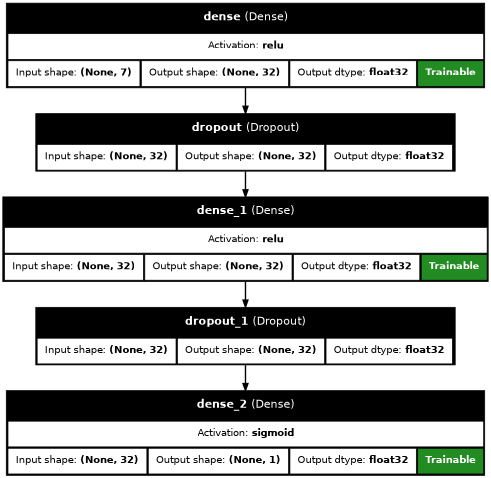

In [33]:
tf.keras.utils.plot_model(
    model,
    to_file                = "model.png",
    show_shapes            = True,
    show_dtype             = True,
    show_layer_names       = True,
    rankdir                = "TB",
    expand_nested          = True,
    dpi                    = 50,
    show_layer_activations = True,
    show_trainable         = True,
)

## TRAINING OF THE MODEL

The ```history``` variable stores the result of the training process. Keras returns a ```History``` object that contains the loss values and evaluation metrics for each epoch, including the validation values when available.

```batch_size=32``` means that the model updates its weights after processing batches of 32 samples at a time. Keras defines ```batch_size``` as the number of samples processed before each gradient update.

```validation_split``` instructs Keras to use 20% of the training data as the validation set. This portion of the data is held out from the training process and is instead used to evaluate the loss function and the model's performance metrics at the end of each training epoch

In [34]:
%%time
# IPython/Jupyter magic command
# measures the execution time of the entire cell
# prints the last 2 lines

# Start measuring time manually
# saves in the start_time variable the current time in seconds
# time.time() gives the number of seconds enlapsed from a certain moment
# I save the exact moment in which the training starts
start_time = time.time()

# Train the neural network
history = model.fit(
    X_train,               # training input
    y_train,               # true labels
    epochs           = 10, # iterations on the dataset
    batch_size       = 32,
    validation_split = 0.2)
# Split the training data into training and validation sets
# 20% of the training data is used for validation

# Compute the elapsed time for training
# time.time() is the actual moment
training_time = time.time() - start_time

# Prints the manually measured time
print(f"\nTraining time: {training_time:.2f} seconds\n")

Epoch 1/10
37746/37746 ━━━━━━━━━━━━━━━━━━━━ 43s 1ms/step - accuracy: 0.7849 - loss: 0.4424 - precision: 0.7971 - recall: 0.7643 - val_accuracy: 0.8102 - val_loss: 0.3990 - val_precision: 0.8330 - val_recall: 0.7761
Epoch 2/10
37746/37746 ━━━━━━━━━━━━━━━━━━━━ 27s 705us/step - accuracy: 0.8032 - loss: 0.4138 - precision: 0.8266 - recall: 0.7673 - val_accuracy: 0.8109 - val_loss: 0.3970 - val_precision: 0.8279 - val_recall: 0.7851
Epoch 3/10
37746/37746 ━━━━━━━━━━━━━━━━━━━━ 27s 707us/step - accuracy: 0.8053 - loss: 0.4106 - precision: 0.8279 - recall: 0.7707 - val_accuracy: 0.8120 - val_loss: 0.3933 - val_precision: 0.8320 - val_recall: 0.7821
Epoch 4/10
37746/37746 ━━━━━━━━━━━━━━━━━━━━ 27s 707us/step - accuracy: 0.8064 - loss: 0.4090 - precision: 0.8291 - recall: 0.7718 - val_accuracy: 0.8121 - val_loss: 0.3959 - val_precision: 0.8579 - val_recall: 0.7482
Epoch 5/10
37746/37746 ━━━━━━━━━━━━━━━━━━━━ 27s 708us/step - accuracy: 0.8069 - loss: 0.4078 - precision: 0.8295 - recall: 0.7726 - va

## EVALUATION

Create the ```evaluation_results``` folder

In [35]:
Path("evaluation_results").mkdir(parents=True,
                                 exist_ok=True)

Apply the trained model to the test data ```X_test``` and store the probabilities/predictions produced by the neural network in the variable ```probability```.

- **Used to make predictions on the test data using the already trained model**
- ```model.predict(X_test)``` passes all the samples contained in ```X_test``` through the neural network and returns the output produced by the model
- ```predict()``` is the method that generates output predictions for input samples, with the computation performed in batches, making it suitable for large datasets

The last layer of the network gives a number between 0 and 1 for each event. Therefore, the ```probability``` variable will contain the probabilities predicted by the model.

This line does **NOT** directly return 0 or 1. Instead, it returns continuous values.

In [36]:
# Generates model predictions on the test set
probability = model.predict(X_test)

probability

11796/11796 ━━━━━━━━━━━━━━━━━━━━ 3s 271us/step


array([[0.17723942],
       [0.03697166],
       [0.02026852],
       ...,
       [0.97355455],
       [0.14912276],
       [0.01108919]], shape=(377458, 1), dtype=float32)

To convert them into classes, you can apply a threshold, for example 0.5:

In [37]:
# Calculate predicted probabilities for the positive class for the two cases
predictions = (probability > 0.5).astype(int)

predictions

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]], shape=(377458, 1))

So
```text
probability >  0.5 → class 1, signal
probability <= 0.5 → class 0, background

### Calculate the ROC curve

Compute the values needed to build the model’s **ROC curve**: it compares the true labels ```y_test``` with the predicted probabilities ```probability``` and returns the **FPR**, **TPR** and the different classification thresholds.

In scikit-learn, ```roc_curve``` computes the ROC curve for binary classification and uses probability estimates or decision scores as input.

In [38]:
fpr, tpr, thresholds = roc_curve(y_test,
                                 probability)

$\text{CM}$ = Confusion Matrix\
Positive = **Signal** = **sgn**\
Negative = **Background** = **bkg**

$$
\text{CM} =
\begin{bmatrix}
\text{TN} & \text{FP}\\
\text{FN} & \text{TP}
\end{bmatrix}
$$

$\text{TN}$ = True Negatives = Number of **bkg** events *correctly* classified as **bkg**\
$\text{FP}$ = False Positives = Numer of **bkg** events *incorreclty* classified as **sgn**\
$\text{FN}$ = False Negatives = Numer of **sgn** events *incorreclty* classified as **bkg**\
$\text{TP}$ = True Positive = Number of **sgn** events *correctly* classified as **sgn**

$\text{TP + FN}$ = ALL **sgn** events\
$\text{TN + FP}$ = ALL **bkg** events

$\text{TP + TN}$ = ALL *correct* events classifications\
$\text{FP + FN}$ = ALL *incorrect* events classifications

$\text{TP + FP}$ = ALL events classified as **sgn**\
$\text{TN + FN}$ = ALL events classified as **bkg**

--------------------------------------------------------------------------------

$\text{FPR}$ stands for **False Positive Rate**.

It measures the proportion of actual **negative/background** events that are *incorrectly classified* as **positive/signal** by the model.

$\text{FPR = FP / (TN + FP)}$

Background events *correctly classified* as signal / all background events (*classified correctly or incorrectly*).

So, a lower $\text{FPR}$ means that the model incorreclty identifies few background events. (false alarms)

In [39]:
# FPR = FP / (TN + FP)
fpr

array([0.        , 0.        , 0.        , ..., 0.99992047, 0.99992047,
       1.        ], shape=(102196,))

$\text{TPR}$ (or $\text{recall}$ or $\text{sensitivity}$) stands for **True Positive Rate**.

It measures the proportion of actual **positive/signal** events that the model *correctly classifies* as **positive/signal**.

$\text{TPR or recall = TP / (TP + FN)}$

Signal events *correctly classified* as signal / all signal events (*classified correctly or incorrectly*).

So, a high $\text{TPR}$ means that the model correctly identifies many signal events. $\text{TPR}$ is also known as $\text{recall}$ or sensitivity.

In [40]:
# TPR or recall = TP / (TP + FN)
tpr

array([0.00000000e+00, 5.29495550e-06, 5.03020772e-04, ...,
       9.99994705e-01, 1.00000000e+00, 1.00000000e+00], shape=(102196,))

In ```roc_curve```, **thresholds** are the possible **cutoff values** used to convert predicted probabilities into classes.

```text
if probability >= threshold → class 1, signal
if probability <  threshold → class 0, background
```

Each threshold gives a different trade-off between **TPR** and **FPR**.
- A lower threshold usually catches more signal events, increasing TPR, but also misclassifies more background as signal, increasing FPR. 
- A higher threshold is stricter, so FPR decreases, but TPR may also decrease. 

In ```sklearn.metrics.roc_curve```, the returned thresholds are the decision values used to compute each corresponding pair of FPR and TPR.

In [41]:
thresholds

array([          inf, 9.9585420e-01, 9.9401802e-01, ..., 3.2275924e-10,
       2.7573169e-10, 6.7606506e-12], shape=(102196,), dtype=float32)

**ROC AUC** means **Area Under the ROC Curve**.

It is a single number that summarizes the overall ability of the model to separate the two classes, **signal** and **background**.

The ROC curve plots **TPR** against **FPR** at different classification thresholds, and the AUC is the area under that curve.

```text
roc_auc = 1.0 → perfect separation
roc_auc = 0.5 → random guessing
roc_auc < 0.5 → worse than random guessing
```

Higher **ROC AUC** means that the model is better at assigning higher probabilities to signal events than to background events.

In [42]:
roc_auc = roc_auc_score(y_test,
                        probability)

roc_auc

np.float64(0.9036333418139457)

### Calculate model accuracy, f1_score & precision

$\text{Accuracy}$ is the **fraction of predictions (sgn or bkg)** that the model *classifies correctly* (as sgn or bkg).

$\text{accuracy = (TP + TN) / (TP + TN + FP + FN)}$

*Correct classifications* / total classifications.

(Accuracy can be misleading if the **dataset is imbalanced**. For example, if you have many more background events than signal events, a high accuracy may still hide poor signal detection. In that case, ROC AUC, precision, recall/TPR, and FPR are also important.)

In [43]:
# accuracy = (TP + TN) / (TP + TN + FP + FN)
accuracy = accuracy_score(y_test,
                          predictions)

accuracy

0.8133567178335073

$\text{Precision}$ (or $\text{positive predictive value}$) measures how many of the events *classified* as **positive/signal** are actually positive/signal.

$\text{precision = TP / (TP + FP)}$

Signal events *correctly classified* as signal / all events *classified as* signal (*correctly* or *incorreclty*).

*Example*: $\text{precision}$ = 0.8 means that the 80% of the events classified as signal are truly signal, while the remaining 20% are background events incorrectly classified as signal.

$\text{Precision}$ tells you how reliable the model is when it predicts **signal**.

In [44]:
# precision = TP / (TP + FP)
precision = precision_score(y_test,
                            predictions)

precision

0.8070406538639063

$\text{F1-score}$ is the **harmonic mean** of **precision** and **recall**, so it combines them into a single value.

$\text{F1-score} = \mathrm{2 \, (precision \cdot recall) / (precision + recall)}$\
$\text{F1-score = 2TP / (2TP + FP + FN)}$

($\text{TN}$ **do not appear in the $\text{F1-score}$ formula**. Indeed, the $\text{F1-score}$ only considers $\text{TP}$, $\text{FP}$, and $\text{FN}$ because it measures the trade-off between precision and recall for the positive/signal class.)

```text
F1-score = 1.0 → perfect model
F1-score = 0.0 → very poor model
```

So a high $\text{F1-score}$ means that the model classifies signal events correctly and does not produce too many false signal predictions, it's a balance between the two.

In [45]:
# F1-score = 2 × (precision × recall) / (precision + recall) =
#          = 2 TP / (2 TP + FP + FN)
f1 = f1_score(y_test,
              predictions)

f1

0.8154222625117244

In [46]:
print(classification_report(y_test,
                            predictions))

              precision    recall  f1-score   support

         0.0       0.82      0.80      0.81    188599
         1.0       0.81      0.82      0.82    188859

    accuracy                           0.81    377458
   macro avg       0.81      0.81      0.81    377458
weighted avg       0.81      0.81      0.81    377458



### Features importance

**Key idea: larger average absolute weight → stronger influence of that feature on the first layer**

```text
larger  sorted weight → feature used more strongly by the model
smaller sorted weight → feature used less strongly by the model
```

Important: this is only an approximate feature-importance method. Neural networks are nonlinear, so large first-layer weights do not always mean that a variable is truly more physically important.

In [47]:
weights         = np.abs(model.get_weights()[0]).mean(axis=1)

This extracts the weights of the **first layer** of the neural network, takes their absolute value, and averages them for each input feature.

```model.get_weights()``` returns the model weights as NumPy arrays; in this case, ```[0]``` selects the first weight matrix. Keras documents ```get_weights()``` as returning the layer weights as a list of NumPy arrays.

In [48]:
sorted_indices  = np.argsort(weights)[::-1]

This **sorts the features by importance**.\
```np.argsort(weights)``` returns the indices that would sort the array;\
```[::-1]``` reverses the order, so the largest weights come first.

In [49]:
sorted_features = [feature_names[i] for i in sorted_indices]

This reorders the feature **names** according to their **importance**.

In [50]:
sorted_weights  = weights[sorted_indices]

sorted_weights

array([4.95166   , 0.6697347 , 0.6522779 , 0.24492928, 0.2429395 ,
       0.20582882, 0.18136601], dtype=float32)

This reorders the **numerical importance values** in the same order as ```sorted_features```.

Higher ```sorted_weights``` means that the corresponding feature has, on average, a stronger connection to the first hidden layer of the neural network.

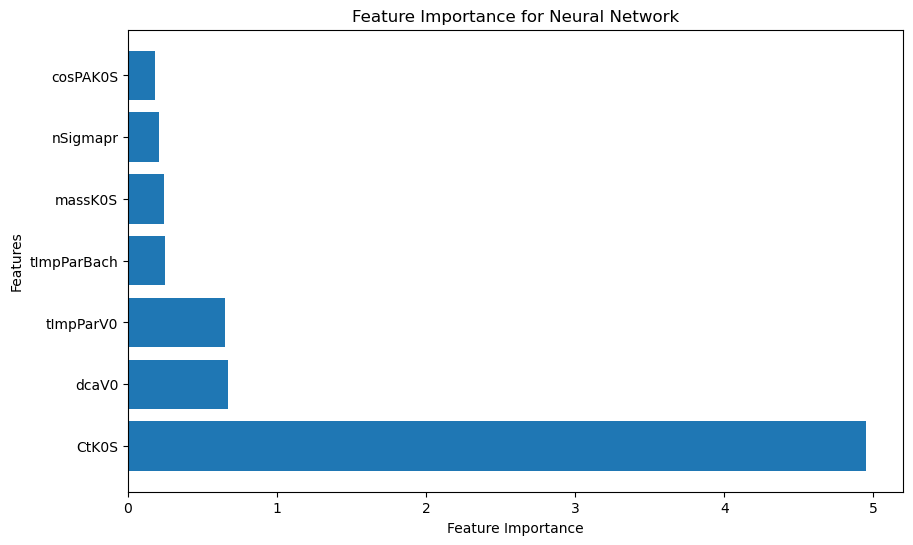

In [51]:
plt.figure(figsize=(10, 6))
plt.barh(sorted_features,
         sorted_weights)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance for Neural Network")

plt.savefig("evaluation_results/feature_importance.pdf")
plt.show()

## PRINT RESULTS

### Save the results to a file

Define the folder path

In [52]:
folder1_path = "evaluation_results"

folder1_path

'evaluation_results'

Define the full path of the output text file to save the main model results.

In [53]:
output_file = os.path.join(folder1_path, "NN" + ".txt")

print(output_file)

# opens the file named output_file in write mode.
# The "w" mode means that the file is created if it does not exist, or overwritten if it already exists.
# The with statement automatically closes the file after the block has finished.
with open(output_file, "w") as f:
# The {} placeholders are replaced by the values of the corresponding variables.
    f.write("accuracy:  {}\n".format(accuracy))  # Accuracy  result
    f.write("f1-score:  {}\n".format(f1))        # f1_score  result
    f.write("precision: {}\n".format(precision)) # precision result
    f.write("ROC AUC:   {}\n".format(roc_auc))   # roc_auc   result
# /t fo tab space
    f.write("fpr\ttpr\n") # Printing of TPR and FPR data
# loops over all the values in the fpr array and
# writes each pair of corresponding FPR and TPR values into the file.
    for i in range(len(fpr)):
        f.write("{}\t{}\n".format(fpr[i], tpr[i]))

evaluation_results/NN.txt


### Metrics display

#### ROC curve

Calculate $\text{Background Rejection = (1 - FPR)}$.

It measures the **fraction of background events** *correctly rejected*, meaning *correctly classified* as background instead of signal. This is the same idea as $\text{specificity}$ or $\text{True Negative Rate (TNR)}$, because $\text{specificity}$ is defined as the ability to identify True Negatives, and it is equal to $\text{(1 - FPR)}$.

```text
background_rejection = 1.0  → all background is rejected
background_rejection = 0.0  → no  background is rejected
```

The output is an array because ```fpr``` is an array of values computed at different ROC thresholds. Therefore, ```background_rejection``` also contains one value for each threshold. The ROC curve uses $\text{Background Rejection}$ and $\text{TPR}$ at different thresholds, so this transformation gives the corresponding background rejection values for those same thresholds.

In [54]:
background_rejection = 1 - fpr

background_rejection

array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
       7.95338257e-05, 7.95338257e-05, 0.00000000e+00], shape=(102196,))

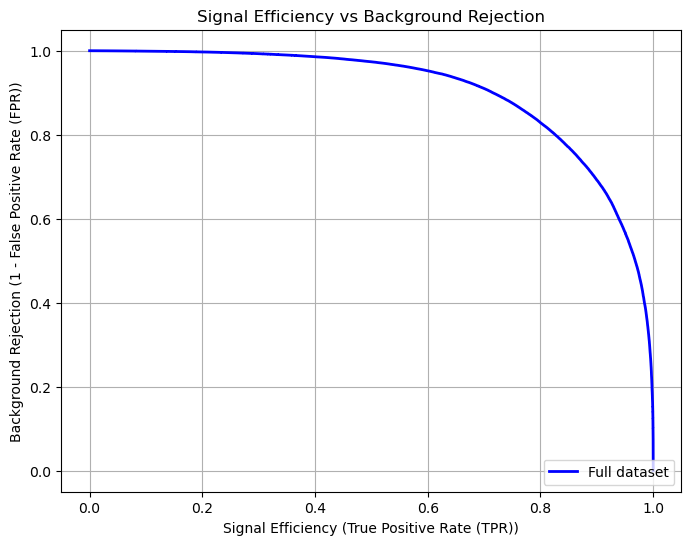

In [55]:
plt.figure(figsize=(8, 6))
plt.plot(tpr,
         background_rejection,
         color = "blue",
         lw    = 2,
         label = "Full dataset")
plt.xlabel("Signal Efficiency (True Positive Rate (TPR))")
plt.ylabel("Background Rejection (1 - False Positive Rate (FPR))")
plt.title("Signal Efficiency vs Background Rejection")
plt.legend(loc="lower right")
plt.grid(True)

plt.savefig("evaluation_results/roc_curve.pdf")
plt.show()

#### Print metrics

In [56]:
print("Accuracy: ", accuracy)
print("F1 Score: ", f1)
print("Precision:", precision)
print("ROC AUC:  ", roc_auc)

Accuracy:  0.8133567178335073
F1 Score:  0.8154222625117244
Precision: 0.8070406538639063
ROC AUC:   0.9036333418139457


#### Confusion Matrix (CM)

A **Confusion Matrix** ($\text{CM}$) is a table used to evaluate a classification model by comparing the true labels with the predicted labels. Rows are true classes and columns are predicted classes.

$\text{CM}$ = Confusion Matrix\
Positive = **Signal** = **sgn**\
Negative = **Background** = **bkg**

$$
\text{CM} =
\begin{bmatrix}
\text{TN} & \text{FP}\\
\text{FN} & \text{TP}
\end{bmatrix}
$$

$\text{TN}$ = ```[0,0]``` = True Negatives = Number of **bkg** events *correctly* classified as **bkg**\
$\text{FP}$ = ```[0,1]``` = False Positives = Numer of **bkg** events *incorreclty* classified as **sgn**\
$\text{FN}$ = ```[1,0]``` = False Negatives = Numer of **sgn** events *incorreclty* classified as **bkg**\
$\text{TP}$ = ```[1,1]``` = True Positive = Number of **sgn** events *correctly* classified as **sgn**

$\text{TP + FN}$ = ALL **sgn** events\
$\text{TN + FP}$ = ALL **bkg** events

$\text{TP + TN}$ = ALL *correct* events classifications\
$\text{FP + FN}$ = ALL *incorrect* events classifications

$\text{TP + FP}$ = ALL events classified as **sgn**\
$\text{TN + FN}$ = ALL events classified as **bkg**

The Confusion Matrix tells **if and where the model is making mistakes showing how many events are correctly or incorrectly classified for each class**.

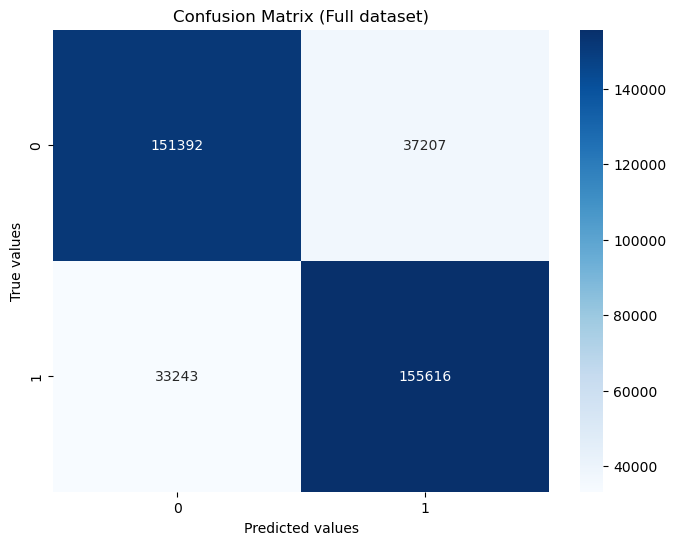

In [57]:
cm = confusion_matrix(y_test,
                      predictions)

# Visualize Confusion Matrix
plt.figure(figsize = (8, 6))
sns.heatmap(cm,
            annot  = True,
            fmt    = "d",
            cmap   = "Blues")
plt.title("Confusion Matrix (Full dataset)")
plt.xlabel("Predicted values")
plt.ylabel("True values")

plt.savefig("evaluation_results/confusion_matrix.pdf")
plt.show()

#### Metrics during epochs

Display the variable ```history```. It's a Keras ```History``` object. ```History``` object is automatically returned by ```fit()``` method during training.

In [58]:
history

Accesses the internal dictionary and prints only its keys converted into a normal Python list. During training, Keras stored these quantities at **each epoch**.

The ```val_``` prefix means that the metric was computed **on the validation set**, not on the training set.

In [59]:
list(history.history.keys())

['accuracy',
 'loss',
 'precision',
 'recall',
 'val_accuracy',
 'val_loss',
 'val_precision',
 'val_recall']

##### Training and Validation Accuracy

This graph shows how the model $\text{accuracy}$ changes during training.

The **blue curve** represents the accuracy on the training set, while the **orange curve** represents the accuracy on the validation set. The values are taken from the Keras `History` object returned by `model.fit()`, which stores the metrics computed at the end of each epoch.

The **x-axis** represents the training epochs, while the **y-axis** represents the accuracy value.

In this case,
- the **training accuracy** increases during the first epochs and then becomes almost stable.
- The **validation accuracy** remains slightly higher than the training accuracy and fluctuates around a stable value.

This suggests that the model is learning from the training data and does **not** show clear signs of overfitting. In fact, the validation accuracy does **not** decrease globally while the training accuracy increases. However, the improvement after the first epochs is quite small, which means that the model reaches a stable performance quickly.

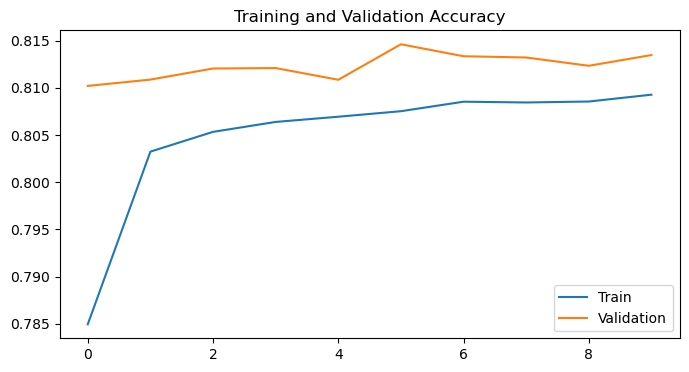

In [60]:
accuracy_hist     = history.history['accuracy']
val_accuracy_hist = history.history['val_accuracy']

plt.figure(figsize=(8, 4))
plt.plot(range(len(accuracy_hist)),
         accuracy_hist,
         label='Train')
plt.plot(range(len(val_accuracy_hist)),
         val_accuracy_hist,
         label='Validation')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.savefig("evaluation_results/metrics_during_epochs_train_validation_accuracy.pdf")
plt.show()

##### Training and Validation Loss

This graph shows how the model **loss** changes during training.

The **blue curve** represents the loss on the training set, while the **orange curve** represents the loss on the validation set. The values are taken from the Keras `History` object returned by `model.fit()`, which stores the metrics computed at the end of each epoch.

The **x-axis** represents the training epochs, while the **y-axis** represents the loss value.

**Lower loss values indicate better model performance.**

In this case,
- the **training loss** decreases steadily, meaning that the model is learning from the training data.
- The **validation loss** remains quite stable and is lower than the training loss.

This suggests that the model does **not** show clear signs of overfitting, because the validation loss does **not** really increase globally while the training loss decreases.

Overall, the model appears to reach a stable performance after the first few epochs. The **small fluctuations** in the validation loss are normal and can depend on the validation sample and the stochastic nature of the training process.

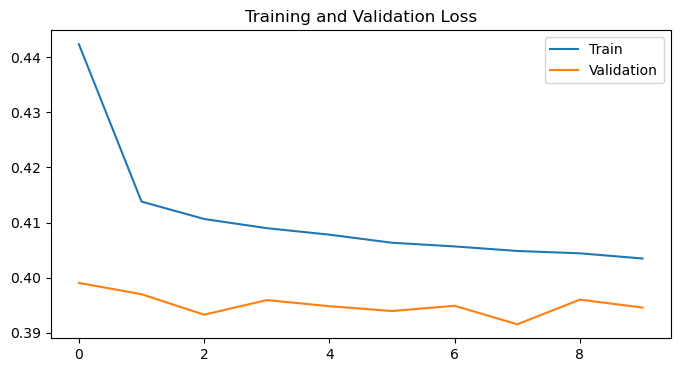

In [61]:
loss_hist     = history.history['loss']
val_loss_hist = history.history['val_loss']

plt.figure(figsize=(8, 4))
plt.plot(range(len(loss_hist)),
         loss_hist,
         label='Train')
plt.plot(range(len(val_loss_hist)),
         val_loss_hist,
         label='Validation')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig("evaluation_results/metrics_during_epochs_train_validation_loss.pdf")
plt.show()

##### Training and Validation F1-score

Calculate $\text{F1-score}$ because it's **not** already present in the ```history``` object.

$\text{F1-score} = \mathrm{2 \, (precision \cdot recall) / (precision + recall)}$\
$\text{F1-score = 2TP / (2TP + FP + FN)}$

This graph shows how the **F1-score** changes during training.

The **blue curve** represents the F1-score on the training set, while the **orange curve** represents the F1-score on the validation set. The F1-score is computed from the values of `precision` and `recall` stored in the Keras `History` object returned by `model.fit()`.

The **x-axis** represents the training epochs, while the **y-axis** represents the F1-score value.

**A higher F1-score indicates a better balance between correctly identifying signal events and avoiding false signal classifications.**

In this case,
- the **training F1-score** increases during the first epochs and then becomes almost stable.
- The **validation F1-score** fluctuates slightly but remains higher than the training F1-score for all epochs.

As before, this suggests that the model is learning progressively from the training data and that there are **no** clear signs of overfitting. In fact, the validation F1-score does **not** decrease while the training F1-score increases. Overall, the model reaches a stable performance after a few epochs.

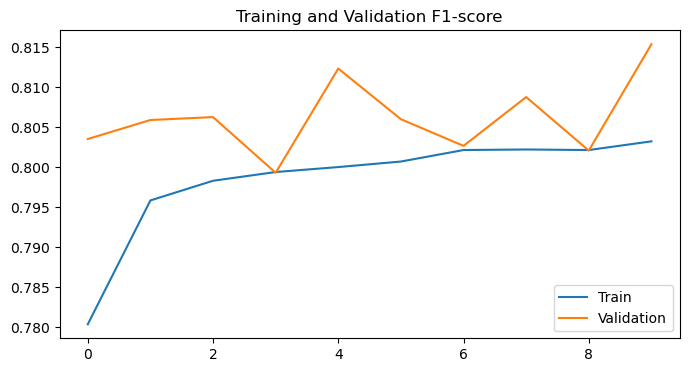

In [62]:
precision_hist     = np.array(history.history['precision'])
recall_hist        = np.array(history.history['recall'])

f1_score_hist      = 2 * (precision_hist * recall_hist) / (precision_hist + recall_hist)


val_precision_hist = np.array(history.history['val_precision'])
val_recall_hist    = np.array(history.history['val_recall'])

val_f1_score_hist  = 2 * (val_precision_hist * val_recall_hist) / (val_precision_hist + val_recall_hist)


plt.figure(figsize=(8, 4))
plt.plot(range(len(f1_score_hist)),
         f1_score_hist,
         label='Train')
plt.plot(range(len(val_f1_score_hist)),
         val_f1_score_hist,
         label='Validation')
plt.legend(loc='lower right')
plt.title('Training and Validation F1-score')

plt.savefig("evaluation_results/metrics_during_epochs_train_validation_F1.pdf")
plt.show()